# Atmospheric Energy Budget
Below I check if I can recreate the atmospheric energy budget.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor_2layer import get_p_eff
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff as get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/odp_const" for i in [5, 20]]
exp_name = [f"thesis_season/column/depth={i}/wind_moist" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/sw_dry" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/no_wind_dry_long_output" for i in [5, 20]]
ds_base = utils.load_ds(exp_name=exp_name, lat_min=30, var_keep=utils.var_keep + ['drag_q', 'olr', 'sphum', 'swdn_toa'],
                        low_lev_only=False, first_month_file=2)
if 'sphum' not in ds_base:
    ds_base['sphum'] = ds_base['temp']*0
    print('Set sphum=0')
# ds_base = isca_tools.load_dataset(exp_name[0], first_month_file=121)[['temp', 'sphum', 'olr', 'flux_lhe',
#                                                                  'flux_t', 'lwdn_sfc', 'lwup_sfc']]

  0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])
ds_base['p_lev'] = ds_base.sigma_atm * ds_base.p_surf.max()
# ds_base['p_lev'] = ds_base.pfull*100
ds_base['atmos_energy_tend'] = get_dmse_dt_xr(ds_base.temp, ds_base.sphum, 0 * ds_base.sphum, ds_base.p_lev,
                                              ds_base.time * utils.day_seconds,
                                              spline_smoothing_factor=1e-5, zonal_mean=True)[1]
ds_base['atmos_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc - ds_base.olr + (ds_base.flux_lhe + ds_base.flux_t)
ds_base['surf_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc + ds_base.flux_lhe + ds_base.flux_t
ds_base['temp_col'] = mass_weighted_vertical_integral(ds_base.temp, ds_base.p_lev, 'pfull', simpson_method=True)


ds_base['sphum_col'] = mass_weighted_vertical_integral(ds_base.sphum, ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['rh_col'] = ds_base['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_base.temp, ds_base.p_lev),
                                                                           ds_base.p_lev, 'pfull', simpson_method=True)
ds_base.attrs['p_eff'] = get_p_eff(float(ds_base.p_surf.max()))
ds_base['temp_col_sphum'] = utils.get_temp_from_sphum_sat_xr(ds_base.sphum_col / ds_base.rh_col, ds_base.p_eff)

if 'no_wind' in exp_name[0]:
    # If no wind, there is very little column humidity, so this gives the best approx
    ds_base['rh_col'] *= 0
    # Remove moisture in all calculations
    # ds_base['atmos_energy_tend'] = get_dmse_dt_xr(ds_base.temp, 0*ds_base.sphum, 0 * ds_base.sphum, ds_base.p_lev,
    #                                           ds_base.time * utils.day_seconds,
    #                                           spline_smoothing_factor=1e-5, zonal_mean=True)[1]
    ds_base['atmos_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc - ds_base.olr + (ds_base.flux_lhe + ds_base.flux_t)
    ds_base['surf_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc + (ds_base.flux_lhe + ds_base.flux_t)

for key in ['col', 'col_sphum']:
    ds_base[f'temp_diseqb_{key}'] = ds_base.temp_atm - ds_base[f'temp_{key}']

ds = utils.get_annual_zonal_mean(ds_base)
if 'no_wind' in exp_name[0]:
    # Take annual harmonic of all variables for simplicity
    for key in ds:
        if 'time' in ds[key].dims:
            try:
                ds[key] = get_fourier_fit_xr(ds.time, ds[key], n_harmonics=1, pad_coefs_phase=True)[0]
            except ValueError:
                print(key)

### Sensitivity to surface heat capacity
Below I just emphasize that having the wrong surface heat capacity can cause quite a large mismatch between the temperature tendency LHS of the surface energy budget and the net fluxes on the RHS.

I had an issue with this before, where I was using $c_p$ of water not ocean to calculate heat capacity.

Below I show that a 2% error in the surface heat capacity can lead to a notable error in the surface temperature tendency term.

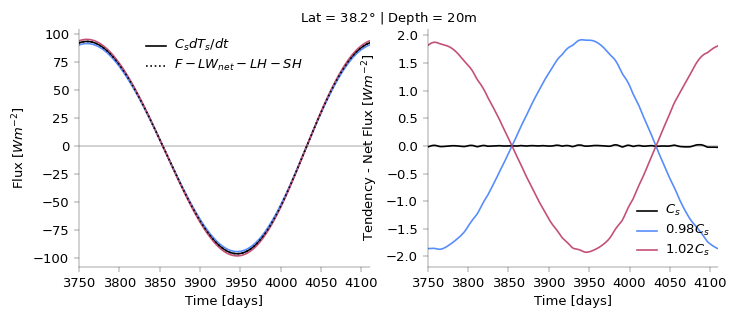

In [4]:
def spline_deriv(time, var, smooth_factor=1e-5):
    spl = UnivariateSpline(time, var, s=smooth_factor)
    return spl.derivative()(time)


depth_plot_ind = 1
lat_plot_ind = 0
spline_deriv_xr = utils.wrap_with_apply_ufunc(spline_deriv,
                                              input_core_dims=[['time'], ['time']],
                                              output_core_dims=[['time']])

fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col']*1.5)
var = [(ds_base.swdn_sfc + ds_base.lwdn_sfc - ds_base.lwup_sfc - ds_base.flux_lhe - ds_base.flux_t
                ).isel(depth=depth_plot_ind, lat=lat_plot_ind)]
for i in range(3):
    heat_cap_use = ds_base.heat_capacity*(1+[0, -0.02, 0.02][i])
    var.append((spline_deriv_xr(ds_base.time * utils.day_seconds, ds_base.temp_surf)
            * heat_cap_use).isel(depth=depth_plot_ind, lat=lat_plot_ind).squeeze())
    ax[0].plot(ds_base.time, var[-1], label='$C_sdT_s/dt$' if i==0 else None, color=['k', 'C0', 'C2'][i])
    ax[1].plot(ds_base.time, (var[-1]-var[0]).rolling(time=10, center=True).mean(), label=['$C_s$', '$0.98C_s$', '$1.02C_s$'][i],
               color=['k', 'C0', 'C2'][i])
ax[0].plot(ds_base.time, var[0], color='k', linestyle=':', label='$F-LW_{net}-LH-SH$')
update_linewidth(fig)
ax[0].set_xlim(3750, 3750 + 360)
# ax[0].set_xlim(13000, 13000 + 360)
ax[0].legend()
ax[1].legend()
ax[0].axhline(0, color='k', lw=ax_linewidth)
ax[1].axhline(0, color='k', lw=ax_linewidth)
ax[0].set_ylabel('Flux [$Wm^{-2}$]')
ax[1].set_ylabel('Tendency - Net Flux [$Wm^{-2}$]')
ax[0].set_xlabel('Time [days]')
ax[1].set_xlabel('Time [days]')
fig.suptitle(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$ | Depth = {ds.depth[depth_plot_ind]:.0f}m', y=0.94)
update_fontsize(fig)
plt.show()

## Atmospheric energy budget sanity check
Below I do a sanity check to ensure the vertically integrated atmosphere energy budget is satisfied:

$$\frac{1}{g} \int_0^{p_s} \frac{\partial(c_pT + L_v q)}{\partial t} dp = F_{\text{net}}$$

I plot the LHS and RHS separately below, and they seem to match well. I plot the error for each latitude below that with shading between 10th and 90th quantile, again it seems to be very small.

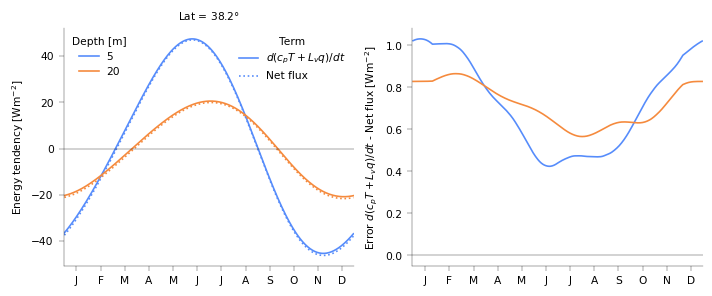

In [5]:
lat_plot_ind = 0
fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col']*1.5)
for i in range(ds.depth.size):
    l1, = ax[0].plot(ds.time, ds.atmos_energy_tend.isel(lat=lat_plot_ind, depth=i), color=f"C{i}",
                  label=f'{ds.depth[i]:.0f}')
    l2, = ax[0].plot(ds.time, ds.atmos_flux_net.isel(lat=lat_plot_ind, depth=i), color=f"C{i}", linestyle=':')
    var = ds.atmos_energy_tend.isel(lat=lat_plot_ind, depth=i) - ds.atmos_flux_net.isel(lat=lat_plot_ind, depth=i)
    ax[1].plot(ds.time, var, color=f"C{i}")
    if i == 0:
        style_handles = [l1, l2]
update_linewidth(fig)
# First legend: depth colors
leg1 = ax[0].legend(title='Depth [m]', loc='upper left')
ax[0].add_artist(leg1)

ax[0].legend(style_handles, ['$d(c_pT+L_vq)/dt$', 'Net flux'], title='Term', loc='upper right')
ax[0].axhline(0, color='k', lw=ax_linewidth)
ax[1].axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
ax[1].set_ylabel('Error $d(c_pT+L_vq)/dt$ - Net flux [Wm$^{-2}$]')
ax[0].set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$')
update_fontsize(fig, 6.5)
plt.show()

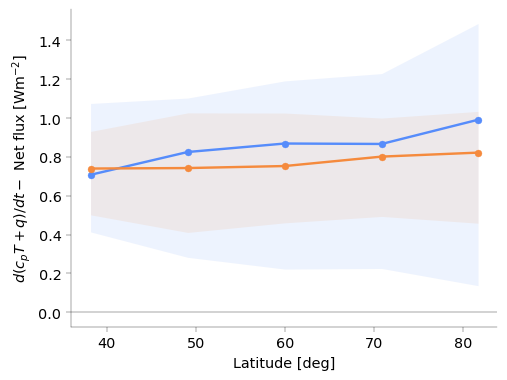

In [6]:
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    ax.plot(ds.lat, np.abs(ds_base.atmos_energy_tend - ds_base.atmos_flux_net).median(dim='time').isel(depth=i),
            color=f"C{i}", marker='.', markersize=10)
    ax.fill_between(ds.lat, np.abs(ds_base.atmos_energy_tend - ds_base.atmos_flux_net).isel(depth=i).quantile(0.1,
                                                                                                        dim='time').squeeze(),
                    np.abs(ds_base.atmos_energy_tend - ds_base.atmos_flux_net).isel(depth=i).quantile(0.9,
                                                                                                dim='time').squeeze(),
                    color=f"C{i}", alpha=0.1, lw=0)
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_xlabel(utils.label_lat)
ax.set_ylabel('$d(c_pT+q)/dt - $ Net flux [Wm$^{-2}$]')
update_fontsize(fig, 6)
plt.show()

## Column humidity decomposition

The column specific humidity is given by: $q_{col} = \int_0^{p_s} q dp/p_s$. We define column relative humidity (standard definition) as $r_{col} = \int_0^{p_s} q dp/\int_0^{p_s} q^* dp$. Then we define effective pressure for humidity calculation according to:

$$p_{col, q} = \frac{\int_0^{p_s} q^* pdp}{\int_0^{p_s} q^* dp} \approx \frac{\beta+1}{\beta+2}p_s$$

where $\beta = \frac{\alpha(T) \Gamma R_d T}{g}$ using hydrostatic balance and assume temperature is dominant cause in variation with pressure of $q^*$, and $\alpha$ is the clausius clapeyron factor. Using values of $T=280$K, $\Gamma = 6.5$K/km, we get $p_{col,q}/p_s = 0.82$. This basically emphasizes that humidity is peaked closer to the surface than the total mass of the atmosphere (which would be $p_s/2$).

Given $p_{col,q}$ and $r_{col}$, we define a column humidity temperature, $T_{col,q}$, which satisfies $q_{col} = r_{col}q^*(T_{col,q}, p_{col,q})$.

We show below that the dominant seasonal variation in $q_{col}$ is then caused by $T_{col, q}$ which in itself has seasonal variation very close to the lowest model level temperature $T_a$.

All except the solid line neglect the seasonal cycle of column humidity, but this seems reasonable and quite a common assumption. The lines differ in what is used for the characteristic column temperature. We need to relate this to lowest model level temperature, but it seems we need to include an empirical factor, rather than a simple shift.

In [7]:
temp_diseqb_fit_coef = {}
for key in ['col', 'col_sphum', 'atm', 'surf']:
    # Force zero intercept as goes through mean
    temp_diseqb_fit_coef[key] = polyfit_phase_xr(ds.temp_atm - ds.temp_atm.mean(dim='time'),
                                                 ds[f'temp_diseqb_{key}'] - ds[f'temp_diseqb_{key}'].mean(dim='time'),
                                                 1, include_phase=False, coef_fix=[None, None, 0]).sel(deg='1')
temp_diseqb_fit_coef['col_amp'], temp_diseqb_fit_coef['col_phase'] = utils.get_fit_coef_complex_xr(ds.temp_col, ds.temp_atm,
                                                                                          ds.time)
temp_diseqb_fit_coef['col_amp'] = 1-temp_diseqb_fit_coef['col_amp']
temp_diseqb_fit_coef['atm_amp'], temp_diseqb_fit_coef['atm_phase'] = utils.get_fit_coef_complex_xr(ds.temp_rad_atm, ds.temp_atm,
                                                                                          ds.time)
temp_diseqb_fit_coef['atm_amp'] = 1-temp_diseqb_fit_coef['atm_amp']

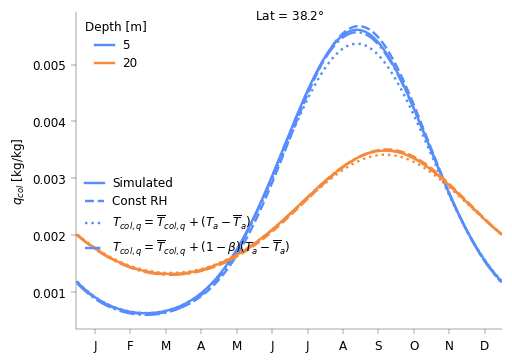

beta = [-0.04 -0.05] for depth = [ 5. 20.]


In [8]:
lat_plot_ind = 0
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    l1, = ax.plot(ds.time, ds.sphum_col.isel(depth=i, lat=lat_plot_ind), color=f"C{i}", label=f'{ds.depth[i]:.0f}')
    l2, = ax.plot(ds.time,
                  (ds.rh_col.mean(dim='time') * sphum_sat(ds.temp_col_sphum, ds.p_eff)).isel(depth=i, lat=lat_plot_ind),
                  color=f"C{i}", linestyle='--')
    temp_col_sphum_use = ds.temp_col_sphum.mean(dim='time') + ds.temp_atm - ds.temp_atm.mean(dim='time')
    l3, = ax.plot(ds.time, (ds.rh_col.mean(dim='time') * sphum_sat(temp_col_sphum_use, ds.p_eff)).isel(depth=i,
                                                                                                       lat=lat_plot_ind),
                  color=f"C{i}", linestyle=':')
    temp_col_sphum_use = ds.temp_col_sphum.mean(dim='time') + (1 - temp_diseqb_fit_coef['col_sphum']) * (
            ds.temp_atm - ds.temp_atm.mean(dim='time'))
    l4, = ax.plot(ds.time, (ds.rh_col.mean(dim='time') * sphum_sat(temp_col_sphum_use, ds.p_eff)).isel(depth=i,
                                                                                                       lat=lat_plot_ind),
                  color=f"C{i}", linestyle='-.')
    # ax.plot(ds.time, ((ds.rh_col - ds.rh_col.mean(dim='time')) * sphum_sat(ds.temp_col_sphum, ds.p_eff)
    #                   ).isel(depth=i, lat=lat_plot_ind), color=f"C{i}", linestyle=':')
    if i == 0:
        style_handles = [l1, l2, l3, l4]
update_linewidth(fig)
# First legend: depth colors
leg1 = ax.legend(title='Depth [m]', loc='upper left')
ax.add_artist(leg1)

ax.legend(style_handles, ['Simulated', 'Const RH', '$T_{col, q}=\\overline{T}_{col, q} + (T_a-\\overline{T}_a)$',
                          '$T_{col, q}=\\overline{T}_{col, q} + (1-\\beta)(T_a-\\overline{T}_a)$'],
          loc='lower left', bbox_to_anchor=(0, 0.2))
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.set_ylabel('$q_{col}$ [kg/kg]')
ax.set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$', y=0.95)
update_fontsize(fig, 5)
plt.show()
print(
    f'beta = {np.round(temp_diseqb_fit_coef["col_sphum"].isel(lat=lat_plot_ind).values, 2)} for depth = {ds.depth.values}')

## Energy tendency decomposition
Below, we split the energy tendency term $\frac{1}{g} \int_0^{p_s} \frac{\partial(c_pT + L_v q)}{\partial t} dp$ into the dry $c_pT$ and moist $L_v q$ terms. We see that the latter is significant at lower latitudes. We can rewrite this as
$\frac{c_p}{g}(p_{low}-p_{up})\frac{dT_{col}}{dt} + \frac{L_v}{g}(p_{low}-p_{up})\frac{dq_{col}}{dt}$.

To get the analytic expression, we need to approximate these two terms with time dependence only in terms of the lowest model level temperature $T(t)$.

For the dry term, we approximate $T_{col} \approx \overline{T}_{col} + (1-\beta_{col})(T_a(t-\tau)-\overline{T}_a)$, where we allow for a phase shift between $T_{col}$ and $T_a$.

For the moist term, we approximate $q_{col} \approx \overline{r}_{col}q^*(\overline{T}_{col, q} + (1-\beta_{col,q})(T_a-\overline{T}_a), p_{col,q})$ as shown above.

We then further approximate $dq^*_{col}/dt \approx \overline{\alpha}_{col,q}\overline{q}^*_{col,q}(1 + \overline{\alpha}_{col,q} (1-\beta_{col,q})(T_a-\overline{T}_a))\frac{dT_a}{dt}$. This sometimes breaksdown, most notably at high latitudes for depth=5m, because we neglected the $(T_a-\overline{T}_a)^2$ and higher order terms in the taylor series expansion of $q^*(T_{col,q}, p_{col,q})$.

In [9]:
def spline_diff(time, var):
    dt = time[-1] - time[-2]
    time_mod = np.append(time, time[-1] + dt)
    var_mod = np.append(var, var[0])
    spline_use = CubicSpline(time_mod, var_mod, bc_type='periodic')
    return spline_use.derivative()(time)


spline_diff_xr = wrap_with_apply_ufunc(spline_diff, input_core_dims=[['time'], ['time']], output_core_dims=[['time']])
get_var_shift_xr = wrap_with_apply_ufunc(get_var_shift, input_core_dims=[['time'], [], [], ['time']],
                                         output_core_dims=[['time']])

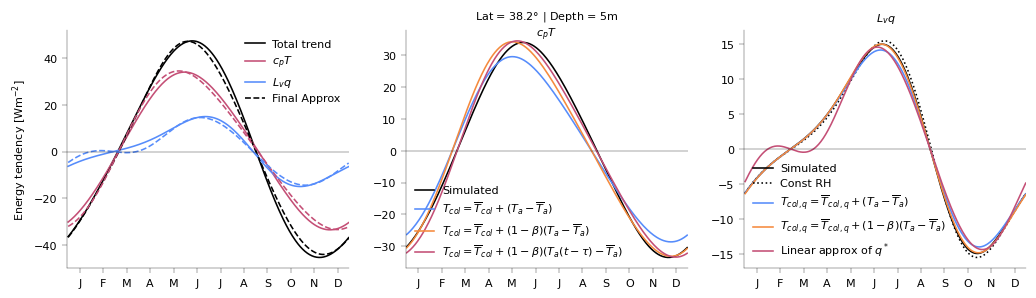

In [10]:
heat_cap_atmos = c_p / g * (ds.p_lev.max() - ds.p_lev.min())
L_v_atmos = L_v / g * (ds.p_lev.max() - ds.p_lev.min())
lat_plot_ind = 0
depth_plot_ind = 0
show_sanity_check = False
ds_use = ds.isel(lat=lat_plot_ind, depth=depth_plot_ind)

fig, ax = plt.subplots(1, 3, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 3 / 2 * 1.5)

ax[0].plot(ds.time, ds_use['atmos_energy_tend'], label='Total trend', color='k')
mse_dry_tend = heat_cap_atmos * spline_diff_xr(ds.time * utils.day_seconds, ds_use.temp_col)
ax[0].plot(ds.time, mse_dry_tend, label='$c_pT$', color='C2')
mse_moist_tend = L_v_atmos * spline_diff_xr(ds.time * utils.day_seconds, ds_use.sphum_col)
ax[0].plot(ds.time, mse_moist_tend, label='$L_v q$', color='C0')
if show_sanity_check:
    ax[0].plot(ds.time, mse_dry_tend + mse_moist_tend, label='$c_pT+L_v q$', color='k', linestyle=':')

ax[1].plot(ds.time, mse_dry_tend, label='Simulated', color='k')
temp_col_use = ds_use.temp_col.mean(dim='time') + ds_use.temp_atm - ds_use.temp_atm.mean(dim='time')
mse_dry_tend = heat_cap_atmos * spline_diff_xr(ds.time * utils.day_seconds, temp_col_use)
ax[1].plot(ds.time, mse_dry_tend, label='$T_{col}=\\overline{T}_{col} + (T_a-\\overline{T}_a)$', color='C0')
temp_col_use = ds_use.temp_col.mean(dim='time') + (
        1 - temp_diseqb_fit_coef['col'].isel(lat=lat_plot_ind, depth=depth_plot_ind)
) * (ds_use.temp_atm - ds_use.temp_atm.mean(dim='time'))
mse_dry_tend = heat_cap_atmos * spline_diff_xr(ds.time * utils.day_seconds, temp_col_use)
ax[1].plot(ds.time, mse_dry_tend, label='$T_{col}=\\overline{T}_{col} + (1-\\beta)(T_a-\\overline{T}_a)$', color='C1')
temp_atm_shift = get_var_shift_xr((ds_use.temp_atm - ds_use.temp_atm.mean()),
                                  temp_diseqb_fit_coef['col_phase'].isel(depth=depth_plot_ind, lat=lat_plot_ind) / (
                                              2 * np.pi / ds.time.size),
                                  None, ds_use.time)
temp_col_use = ds_use.temp_col.mean() + (
        1 - temp_diseqb_fit_coef['col_amp'].isel(lat=lat_plot_ind, depth=depth_plot_ind)
) * temp_atm_shift
mse_dry_tend = heat_cap_atmos * spline_diff_xr(ds.time * utils.day_seconds, temp_col_use)
ax[1].plot(ds.time, mse_dry_tend, label='$T_{col}=\\overline{T}_{col} + (1-\\beta)(T_a(t-\\tau)-\\overline{T}_a)$',
           color='C2')

ax[2].plot(ds.time, mse_moist_tend, label='Simulated', color='k')
mse_moist_tend = L_v_atmos * spline_diff_xr(ds.time * utils.day_seconds,
                                            ds_use.rh_col.mean() * sphum_sat(ds_use.temp_col_sphum, ds.p_eff))
ax[2].plot(ds.time, mse_moist_tend, label='Const RH', color='k', linestyle=':')
temp_col_sphum_use = ds_use.temp_col_sphum.mean() + ds_use.temp_atm - ds_use.temp_atm.mean()
mse_moist_tend = L_v_atmos * spline_diff_xr(ds.time * utils.day_seconds,
                                            ds_use.rh_col.mean() * sphum_sat(temp_col_sphum_use, ds.p_eff))
ax[2].plot(ds.time, mse_moist_tend, label='$T_{col, q}=\\overline{T}_{col, q} + (T_a-\\overline{T}_a)$', color='C0')
temp_col_sphum_use = ds_use.temp_col_sphum.mean() + (
        1 - temp_diseqb_fit_coef['col_sphum'].isel(lat=lat_plot_ind, depth=depth_plot_ind)
) * (ds_use.temp_atm - ds_use.temp_atm.mean())
mse_moist_tend = L_v_atmos * spline_diff_xr(ds.time * utils.day_seconds,
                                            ds_use.rh_col.mean() * sphum_sat(temp_col_sphum_use, ds.p_eff))
ax[2].plot(ds.time, mse_moist_tend, label='$T_{col, q}=\\overline{T}_{col, q} + (1-\\beta)(T_a-\\overline{T}_a)$',
           color='C1')
mse_moist_tend = L_v_atmos * spline_diff_xr(ds.time * utils.day_seconds,
                                            ds_use.temp_atm)
alpha_av = clausius_clapeyron_factor(temp_col_sphum_use.mean(), ds_use.p_eff)
sphum_sat_av = sphum_sat(temp_col_sphum_use.mean(), ds_use.p_eff)
# Do taylor series expansion
# alpha_sphum_sat_use = alpha_av * sphum_sat_av * (1 + (alpha_av - 2/temp_col_sphum_use.mean()) *
#                                                  (temp_col_sphum_use - temp_col_sphum_use.mean()))   # if expand alpha too, makes little diff
alpha_sphum_sat_use = alpha_av * sphum_sat_av * (1 + alpha_av *
                                                 (temp_col_sphum_use - temp_col_sphum_use.mean()))
mse_moist_tend *= ds_use.rh_col.mean() * alpha_sphum_sat_use * \
                  (1 - temp_diseqb_fit_coef['col_sphum'].isel(lat=lat_plot_ind, depth=depth_plot_ind))
ax[2].plot(ds.time, mse_moist_tend, label='Linear approx of $q^*$',
           color='C2')

ax[0].plot(ds.time, mse_dry_tend + mse_moist_tend, color='k', linestyle='--', label='Final Approx')
ax[0].plot(ds.time, mse_dry_tend, color='C2', linestyle='--')
ax[0].plot(ds.time, mse_moist_tend, color='C0', linestyle='--')

update_linewidth(fig)
ax[0].legend()
ax[1].legend()
ax[2].legend()
for ax_use in ax:
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[1].set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$ | Depth = {ds_use.depth:.0f}m' + '\n$c_pT$', y=0.94)
ax[2].set_title('$L_vq$')
update_fontsize(fig, base_fontsize=7)
plt.show()

### Relating temperature variables to lowest model level
#### Empirical fitting of vertically integrated temperatures
We see that the phase delay, with the seasonal cycle of $T_{col}$ delayed compared to that of $T_a$ is noticeable. Whereas this is not the case for $T_{col,q}$ which is characteristic of the lower troposphere so is not surpising that this is closer to $T_a$.

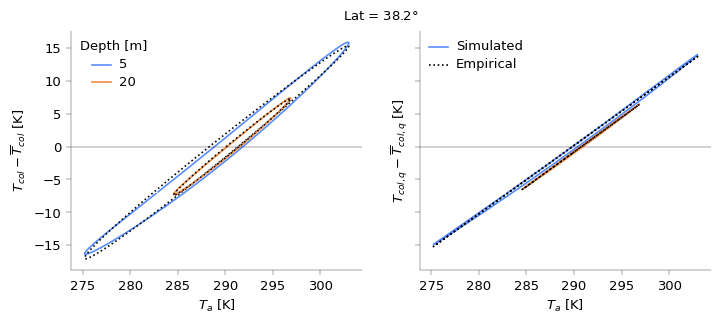

In [11]:
lat_plot_ind = 0
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ds_use = ds.isel(depth=i, lat=lat_plot_ind)
    ax[0].plot(ds_use.temp_atm, ds_use.temp_col - ds_use.temp_col.mean(), color=f'C{i}', label=f'{ds.depth[i]:.0f}')
    temp_atm_shift = get_var_shift_xr((ds_use.temp_atm - ds_use.temp_atm.mean()),
                                      temp_diseqb_fit_coef['col_phase'].isel(depth=i, lat=lat_plot_ind) / (
                                                  2 * np.pi / ds.time.size),
                                      None, ds_use.time)
    temp_col_use = (
                           1 - temp_diseqb_fit_coef['col_amp'].isel(lat=lat_plot_ind, depth=i)
                   ) * temp_atm_shift
    ax[0].plot(ds_use.temp_atm, temp_col_use, color=f'k', linestyle=':')
    ax[1].plot(ds_use.temp_atm, ds_use.temp_col_sphum - ds_use.temp_col_sphum.mean(), color=f'C{i}',
               label='Simulated' if i == 0 else None)
    ax[1].plot(ds_use.temp_atm, (1 - temp_diseqb_fit_coef['col_sphum'].isel(lat=lat_plot_ind, depth=i)) *
               (ds_use.temp_atm - ds_use.temp_atm.mean()), color='k', linestyle=':',
               label='Empirical' if i == 0 else None)
update_linewidth(fig)
for ax_use in ax:
    ax_use.axhline(0, color='k', lw=ax_linewidth)
    ax_use.set_xlabel('$T_a$ [K]')
ax[0].legend(title='Depth [m]')
ax[1].legend()
ax[0].set_ylabel('$T_{col}-\overline{T}_{col}$ [K]')
ax[1].set_ylabel('$T_{col,q}-\overline{T}_{col,q}$ [K]')
fig.suptitle(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$', y=0.95)
update_fontsize(fig)
plt.show()

#### Vertically integrated temperatures and radiative temperatures
For the flux decomposition below, we also need to relate the two radiative temperatures (one to the surface, and one to space) to the lowest model level temperature. We include those in the plot below.

I only account for a time delay in the column weighted temperature - makes sense as most dominated definition from upper troposphere. Then for surface radiative temperature, it is just a shift in the time mean value. For the other two, I also need an empirical gradient variable. These fits are shown by the black lines.

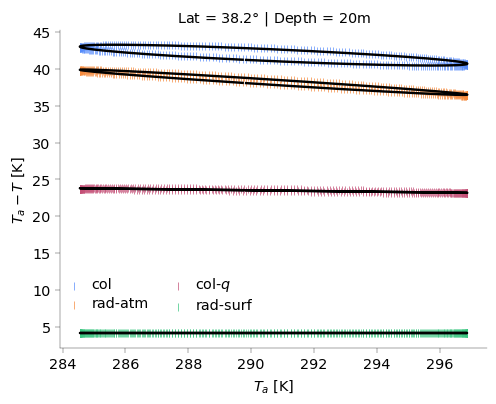

In [12]:
lat_plot_ind = 0
depth_plot_ind = 1
ds_use = ds.isel(lat=lat_plot_ind, depth=depth_plot_ind)
empirical_coef_use = {key: temp_diseqb_fit_coef[key].isel(lat=lat_plot_ind, depth=depth_plot_ind) for key in
                      temp_diseqb_fit_coef}

fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])

# Mass weighted col
ax.scatter(ds_use.temp_atm, ds_use.temp_atm - ds_use.temp_col, color=f"C0", marker='|', s=30, label='col')
temp_atm_shift = get_var_shift_xr((ds_use.temp_atm - ds_use.temp_atm.mean()),
                                  empirical_coef_use['col_phase'] / (2 * np.pi / ds.time.size),
                                  None, ds_use.time)
temp_use = (1 - empirical_coef_use['col_amp']) * temp_atm_shift + ds_use.temp_col.mean()
ax.plot(ds_use.temp_atm, ds_use.temp_atm - temp_use, color='k')

# Radiative - atm
ax.scatter(ds_use.temp_atm, ds_use.temp_atm - ds_use.temp_rad_atm, color='C1', marker='|', s=30, label='rad-atm')
# temp_use = (1 - empirical_coef_use['atm']) * (ds_use.temp_atm - ds_use.temp_atm.mean()) + ds_use.temp_rad_atm.mean()
temp_atm_shift = get_var_shift_xr((ds_use.temp_atm - ds_use.temp_atm.mean()),
                                  empirical_coef_use['atm_phase'] / (2 * np.pi / ds.time.size),
                                  None, ds_use.time)
temp_use = (1 - empirical_coef_use['atm_amp']) * temp_atm_shift + ds_use.temp_rad_atm.mean()
ax.plot(ds_use.temp_atm, ds_use.temp_atm - temp_use, color='k')

# Sphum weighted col
ax.scatter(ds_use.temp_atm, ds_use.temp_atm - ds_use.temp_col_sphum, color='C2', marker='|', s=30, label='col-$q$')
temp_use = (1 - empirical_coef_use['col_sphum']) * (
            ds_use.temp_atm - ds_use.temp_atm.mean()) + ds_use.temp_col_sphum.mean()
ax.plot(ds_use.temp_atm, ds_use.temp_atm - temp_use, color='k')

# Radiative - surf
ax.scatter(ds_use.temp_atm, ds_use.temp_atm - ds_use.temp_rad_surf, color='C3', marker='|', s=30, label='rad-surf')
temp_use = (1 - 0 * empirical_coef_use['surf']) * (
            ds_use.temp_atm - ds_use.temp_atm.mean()) + ds_use.temp_rad_surf.mean()
ax.plot(ds_use.temp_atm, ds_use.temp_atm - temp_use, color='k')

update_linewidth(fig)

ax.legend(ncol=2, loc=(0, 0.1))
ax.set_xlabel('$T_a$ [K]')
ax.set_ylabel('$T_a - T$ [K]')
ax.set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$ | Depth = {ds_use.depth:.0f}m')
update_fontsize(fig, 6)

plt.show()

### Flux decomposition
Below I decompose the total flux into the atmosphere into the individual contributions. I then approximate the individual terms such that they depend linearly on surface or atmospheric temperature anomaly only. This is such that an analytic solution can be achieved.

It seems that the most notable approximation is that of latent heat flux, because this shows nonlinear dependence on temperature due to Clausius Clapeyron. However, this is only the case for the small mixed layer depth simulation, but over land latent heat flux would be reduced due to limited soil moisture anyway.


In [13]:
def get_lw_surf_to_atmos(ds, taylor=False):
    if taylor:
        temp_av = ds.temp_surf.mean(dim='time')
        return 4 * (1 - np.exp(-ds.odp_surf)) * Stefan_Boltzmann * temp_av ** 3 * (ds.temp_surf - temp_av)
    else:
        return (1 - np.exp(-ds.odp_surf)) * Stefan_Boltzmann * ds.temp_surf ** 4


def get_lw_atmos_to_space(ds, taylor=False, empirical_coef_amp=None, empirical_coef_phase=None):
    if empirical_coef_amp is not None:
        temp_atm_use = ds.temp_atm - ds.temp_atm.mean(dim='time')
        if empirical_coef_phase is not None:
            temp_atm_use = get_var_shift_xr(temp_atm_use, empirical_coef_phase / (2 * np.pi / ds.time.size),
                                            None, ds.time)
        temp_rad = ds.temp_rad_atm.mean(dim='time') + temp_atm_use * (1 - empirical_coef_amp)
    else:
        temp_rad = ds.temp_rad_atm
    if taylor:
        temp_rad_av = temp_rad.mean(dim='time')
        return Stefan_Boltzmann * (1 - np.exp(-ds.odp_surf)) * 4 * temp_rad_av ** 3 * (temp_rad - temp_rad_av)
    else:
        return Stefan_Boltzmann * temp_rad ** 4 * (1 - np.exp(-ds.odp_surf))


def get_lw_atmos_to_surf(ds, taylor=False, empirical_coef=None):
    if empirical_coef is not None:
        temp_atm_use = ds.temp_atm - ds.temp_atm.mean(dim='time')
        temp_rad = ds.temp_rad_surf.mean(dim='time') + temp_atm_use * (
                    1 - empirical_coef)
    else:
        temp_rad = ds.temp_rad_surf
    if taylor:
        temp_rad_av = temp_rad.mean(dim='time')
        return Stefan_Boltzmann * (1 - np.exp(-ds.odp_surf)) * 4 * temp_rad_av ** 3 * (temp_rad - temp_rad_av)
    else:
        return Stefan_Boltzmann * temp_rad ** 4 * (1 - np.exp(-ds.odp_surf))


def get_lw_surf_net(ds, taylor=False, empirical_coef=None):
    if taylor:
        temp_surf_av = ds.temp_surf.mean(dim='time')
        return 4 * Stefan_Boltzmann * temp_surf_av ** 3 * (ds.temp_surf - temp_surf_av) - get_lw_atmos_to_surf(ds,
                                                                                                               taylor,
                                                                                                               empirical_coef)
    else:
        return Stefan_Boltzmann * ds.temp_surf ** 4 - get_lw_atmos_to_surf(ds, taylor, empirical_coef)


def get_flux_lh(ds, taylor=False):
    if taylor:
        ds_av = ds.mean(dim='time', keep_attrs=True)
        gamma = utils.get_sensitivity_lh(ds_av.temp_surf, ds_av.temp_atm, ds_av.rh_flux_q, ds_av.w_atm, ds_av.drag_coef,
                                         ds_av.p_surf,
                                         ds_av.sigma_atm.isel(pfull=-1))
        return gamma['temp_surf'] * (ds.temp_surf - ds_av.temp_surf) + gamma['temp_atm'] * (
                    ds.temp_atm - ds_av.temp_atm) + ds_av.flux_lhe
    else:
        return ds.flux_lhe


def get_flux_sh(ds, taylor=False):
    if taylor:
        ds_av = ds.mean(dim='time', keep_attrs=True)
        gamma = utils.get_sensitivity_sh(ds_av.temp_surf, ds_av.temp_atm, ds_av.w_atm, ds_av.drag_coef, ds_av.p_surf,
                                         ds_av.sigma_atm.isel(pfull=-1))
        return gamma['temp_surf'] * (ds.temp_surf - ds_av.temp_surf) + gamma['temp_atm'] * (
                    ds.temp_atm - ds_av.temp_atm) + ds_av.flux_lhe
    else:
        return ds.flux_t


get_anom = lambda x: x - x.mean(dim='time')

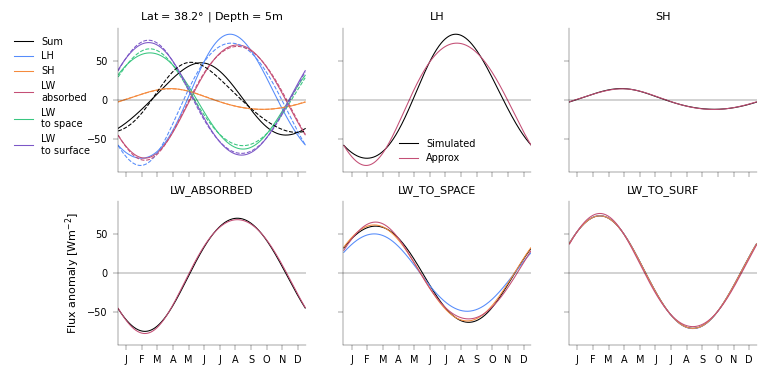

In [14]:
lat_plot_ind = 0
depth_plot_ind = 0
show_sanity_check = False
ds_use = ds.isel(lat=lat_plot_ind, depth=depth_plot_ind)
empirical_coef_use = {key: temp_diseqb_fit_coef[key].isel(lat=lat_plot_ind, depth=depth_plot_ind) for key in
                      ['atm', 'surf', 'atm_amp', 'atm_phase']}

fig, ax = plt.subplots(2, 3, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()
ax[0].plot(ds.time, get_anom(ds_use.atmos_flux_net), label=f"Sum", color='k')
ax[0].plot(ds.time, get_anom(get_flux_lh(ds_use)), label=f"LH", color='C0')
ax[0].plot(ds.time, get_anom(get_flux_sh(ds_use)), label=f"SH", color='C1')
ax[0].plot(ds.time, get_anom(get_lw_surf_to_atmos(ds_use)), label=f"LW\nabsorbed", color='C2')
ax[0].plot(ds.time, -get_anom(get_lw_atmos_to_space(ds_use)), label=f"LW\nto space", color='C3')
ax[0].plot(ds.time, -get_anom(get_lw_atmos_to_surf(ds_use)), label=f"LW\nto surface", color='C4')

flux_approx_use = {}
ax[1].plot(ds.time, get_anom(get_flux_lh(ds_use)), color='k', label='Simulated')
flux_approx_use['lh'] = get_anom(get_flux_lh(ds_use, True))
ax[1].plot(ds.time, flux_approx_use['lh'], color='C2', label='Approx')

ax[2].plot(ds.time, get_anom(get_flux_sh(ds_use)), color='k')
flux_approx_use['sh'] = get_anom(get_flux_sh(ds_use, True))
ax[2].plot(ds.time, flux_approx_use['sh'], color='C2')

ax[3].plot(ds.time, get_anom(get_lw_surf_to_atmos(ds_use)), color='k')
flux_approx_use['lw_absorbed'] = get_anom(get_lw_surf_to_atmos(ds_use, True))
ax[3].plot(ds.time, flux_approx_use['lw_absorbed'], color='C2')

ax[4].plot(ds.time, -get_anom(get_lw_atmos_to_space(ds_use)), color='k')
ax[4].plot(ds.time, -get_anom(get_lw_atmos_to_space(ds_use, empirical_coef_amp=0)), color='C0')
ax[4].plot(ds.time, -get_anom(get_lw_atmos_to_space(ds_use, False, empirical_coef_use['atm'])), color='C1')
flux_approx_use['lw_to_space'] = -get_anom(get_lw_atmos_to_space(ds_use, True, empirical_coef_use['atm_amp'],
                                                                 empirical_coef_use['atm_phase']))
ax[4].plot(ds.time, flux_approx_use['lw_to_space'], color='C2')

# ax[5].plot(ds.time, -get_anom(ds_use.lwdn_sfc), color='k', linestyle=':')
ax[5].plot(ds.time, -get_anom(get_lw_atmos_to_surf(ds_use)), color='k')
ax[5].plot(ds.time, -get_anom(get_lw_atmos_to_surf(ds_use, empirical_coef=0)), color='C0')
ax[5].plot(ds.time, -get_anom(get_lw_atmos_to_surf(ds_use, False, empirical_coef_use['surf'])), color='C1')
flux_approx_use['lw_to_surf'] = -get_anom(get_lw_atmos_to_surf(ds_use, True, empirical_coef_use['surf']))
ax[5].plot(ds.time, flux_approx_use['lw_to_surf'], color='C2')

for i, key in enumerate(flux_approx_use):
    ax[0].plot(ds.time, flux_approx_use[key], color=f'C{i}', linestyle='--')
    ax[i + 1].set_title(key.upper())
ax[0].plot(ds.time, sum(flux_approx_use.values()), color='k', linestyle='--')

update_linewidth(fig)
ax[0].legend(ncol=1, bbox_to_anchor=(-0.1, 1))
ax[1].legend()
ax[0].set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$ | Depth = {ds_use.depth:.0f}m')
for ax_use in ax:
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[3].set_ylabel('Flux anomaly [Wm$^{-2}$]')
plt.show()
# ax[0].plot(ds.time, ds_use.lwdn_sfc)

## Surface energy budget
The surface energy budget is $C_s \frac{dT_s}{dt} = F(t) - (\sigma T_s^4 - LW^{\downarrow}) - LH - SH$.

Below I ensure the LHS and RHS match up, before approximating the RHS as done above for the fluxes involved in the atmospheric energy budget. Again, the latent heat flux is the most significant approximation here.

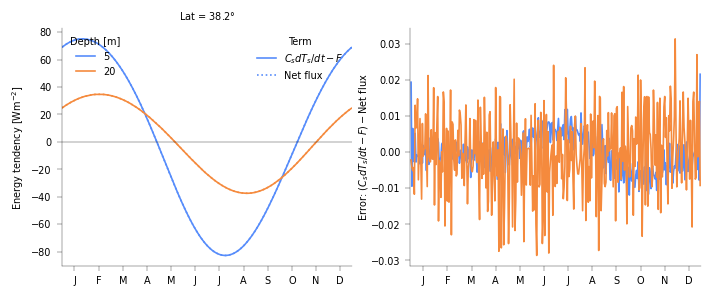

In [15]:
lat_plot_ind = 0
fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ds_use = ds.isel(lat=lat_plot_ind, depth=i)
    # sw_use = fourier_series(ds.time, [float(ds_use.swdn_sfc.mean()*2), -coef_sw_amp.isel(lat=lat_plot_ind, depth=i)],
    #                         [0, 0], pad_coefs_phase=True)
    sw_use = ds_use.swdn_sfc
    var = [ds_use.heat_capacity * spline_diff_xr(ds.time * utils.day_seconds, ds_use.temp_surf) - sw_use]
    l1, = ax[0].plot(ds.time, (var[0] - var[0].mean()), color=f"C{i}",
                     label=f'{ds.depth[i]:.0f}')
    var.append(-ds_use.lwup_sfc + ds_use.lwdn_sfc - ds_use.flux_t - ds_use.flux_lhe)
    l2, = ax[0].plot(ds.time, var[1] - var[1].mean(), color=f"C{i}", linestyle=':')
    var.append(-ds_use.surf_flux_net)
    ax[1].plot(ds.time, var[0] - var[1], color=f"C{i}")
    # ax[1].plot(ds.time.values[:-5], var[0][5:].values-var[1][:-5].values, color=f"C{i}")
    # ax[1].plot(ds.time, var[2]-var[1], color=f"C{i}", linestyle=':')  # sanity check that sum is not the same
    if i == 0:
        style_handles = [l1, l2]
update_linewidth(fig)
# First legend: depth colors
leg1 = ax[0].legend(title='Depth [m]', loc='upper left')
ax[0].add_artist(leg1)

ax[0].legend(style_handles, ['$C_sdT_s/dt-F$', 'Net flux'], title='Term', loc='upper right')
ax[0].axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
ax[0].set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$')
ax[1].set_ylabel('Error: $(C_sdT_s/dt-F) - $Net flux', labelpad=-0.1)
update_fontsize(fig, 6)
plt.show()

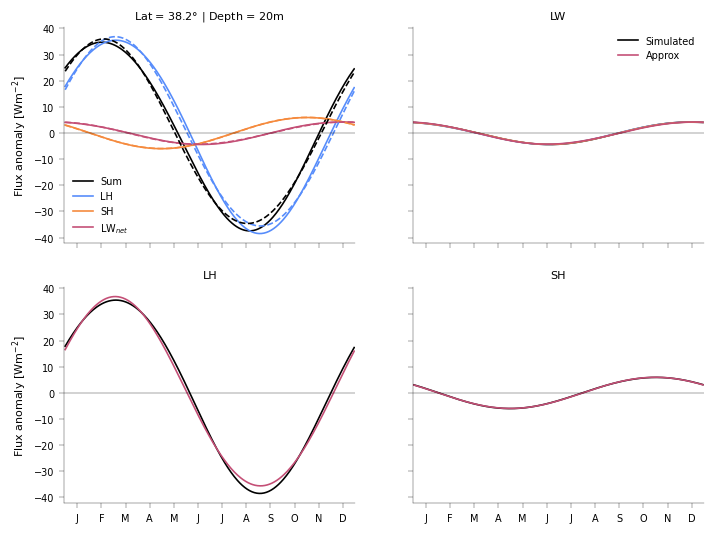

In [16]:
lat_plot_ind = 0
depth_plot_ind = 1
show_sanity_check = False
ds_use = ds.isel(lat=lat_plot_ind, depth=depth_plot_ind)
empirical_coef_use = {key: temp_diseqb_fit_coef[key].isel(lat=lat_plot_ind, depth=depth_plot_ind) for key in
                      ['atm', 'surf']}

fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()
ax[0].plot(ds.time, -get_anom(ds_use.lwup_sfc - ds_use.lwdn_sfc + ds_use.flux_t + ds_use.flux_lhe), label=f"Sum",
           color='k')
ax[0].plot(ds.time, -get_anom(get_flux_lh(ds_use)), label=f"LH", color='C0')
ax[0].plot(ds.time, -get_anom(get_flux_sh(ds_use)), label=f"SH", color='C1')
ax[0].plot(ds.time, -get_anom(ds_use.lwup_sfc - ds_use.lwdn_sfc), label="LW$_{net}$", color='C2')
# ax[0].plot(ds.time, -get_anom(get_lw_atmos_to_space(ds_use)), label=f"LW\nto space", color='C3')
# ax[0].plot(ds.time, -get_anom(get_lw_atmos_to_surf(ds_use)), label=f"LW\nto surface", color='C4')


flux_approx_use = {}

ax[2].set_title('LH')
ax[2].plot(ds.time, -get_anom(get_flux_lh(ds_use)), color='k', label='Simulated')
flux_approx_use['lh'] = -get_anom(get_flux_lh(ds_use, True))
ax[2].plot(ds.time, flux_approx_use['lh'], color='C2', label='Approx')

ax[3].set_title('SH')
ax[3].plot(ds.time, -get_anom(get_flux_sh(ds_use)), color='k')
flux_approx_use['sh'] = -get_anom(get_flux_sh(ds_use, True))
ax[3].plot(ds.time, flux_approx_use['sh'], color='C2')

ax[1].set_title('LW')
ax[1].plot(ds.time, -get_anom(get_lw_surf_net(ds_use)), color='k', label='Simulated')
ax[1].plot(ds.time, -get_anom(get_lw_surf_net(ds_use, empirical_coef=0)), color='C0')
ax[1].plot(ds.time, -get_anom(get_lw_surf_net(ds_use, False, empirical_coef_use['surf'])), color='C1')
flux_approx_use['lw'] = -get_anom(get_lw_surf_net(ds_use, True, empirical_coef_use['surf']))
ax[1].plot(ds.time, flux_approx_use['lw'], color='C2', label='Approx')
#
for i, key in enumerate(flux_approx_use):
    ax[0].plot(ds.time, flux_approx_use[key], color=f'C{i}', linestyle='--')
ax[0].plot(ds.time, sum(flux_approx_use.values()), color='k', linestyle='--')
#
update_linewidth(fig)
ax[0].legend()
ax[1].legend()
ax[0].set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$ | Depth = {ds_use.depth:.0f}m')
for ax_use in ax:
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Flux anomaly [Wm$^{-2}$]')
ax[2].set_ylabel('Flux anomaly [Wm$^{-2}$]')
plt.show()

### Approximating Flux with $\lambda$ feedback parameters
Below I do a sanity check that the computed $\lambda$ feedback parameters correctly approximate the tendency of both the surface temperature, and the atmospheric column energy.

In [17]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
coef_amp = np.abs(coef_amp.sel(harmonic=1))
coef_phase = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

f = 1 / (ds.time.size * utils.day_seconds)
heat_cap_multiplier = get_heat_capacity(c_p_ocean, rho_ocean,
                                        coef_sw_amp * np.sin(coef_phase) / (2 * np.pi * f) / coef_amp,
                                        True) / ds.depth
lambda_s1_eff = coef_sw_amp * np.cos(coef_phase) / coef_amp

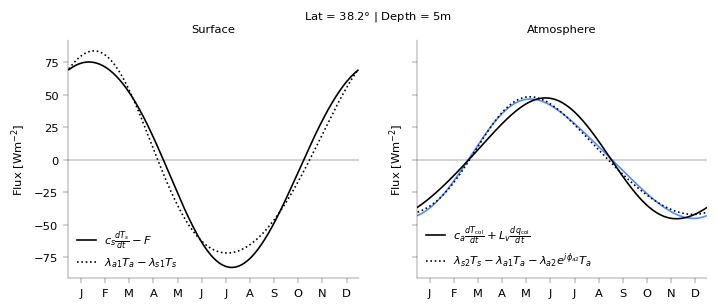

In [18]:
lat_plot_ind = 0
depth_plot_ind = 0

ds_use = ds.isel(lat=lat_plot_ind, depth=depth_plot_ind)
ds_use['sigma_atm'] = ds_use['sigma_atm'].sel(pfull=np.inf, method='nearest')
empirical_coef_use = {key: temp_diseqb_fit_coef[key].isel(lat=lat_plot_ind, depth=depth_plot_ind) for key in
                      ['atm', 'surf', 'atm_amp', 'atm_phase',
                       'col_amp', 'col_phase', 'col_sphum']}
arg_names = list(inspect.signature(get_feedback_params).parameters.keys())
args_use = {key: ds_use.mean(dim='time')[key] for key in arg_names if key in ds_use}
args_use['rh_atm'] = ds_use.rh_flux_q
args_use['drag_coef'] = ds_use.drag_coef
args_use['temp_rad_surf_coef_amp'] = temp_diseqb_fit_coef['surf'].isel(lat=lat_plot_ind, depth=depth_plot_ind)
args_use['temp_rad_atm_coef_amp'] = (temp_diseqb_fit_coef['atm_amp']).isel(lat=lat_plot_ind, depth=depth_plot_ind)
lambda_s1_use, lambda_s2, lambda_a1, lambda_a2 = get_feedback_params(**args_use)


fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax[0].set_title('Surface')
var = ds_use.heat_capacity * spline_diff_xr(ds_use.time * utils.day_seconds, ds_use.temp_surf) - ds_use.swdn_sfc
ax[0].plot(ds.time, var - var.mean(), color='k',
           label='$c_s\\frac{dT_s}{dt}-F$')
var = -lambda_s1_use * ds_use.temp_surf + lambda_a1 * ds_use.temp_atm
ax[0].plot(ds.time, var - var.mean(), color='k', linestyle=':', label='$\\lambda_{a1}T_a - \\lambda_{s1}T_s$')

ax[1].set_title('Atmosphere')
heat_cap_atmos = c_p * float(ds['p_lev'].max() - ds['p_lev'].min()) / g
ax[1].plot(ds.time, spline_diff_xr(ds_use.time * utils.day_seconds, heat_cap_atmos * ds_use.temp_col +
                                   L_v / c_p * heat_cap_atmos * ds_use.sphum_col),
           color='k', label='$c_a\\frac{dT_{\\text{col}}}{dt} + L_v\\frac{dq_{\\text{col}}}{dt}$')

lhs_approx = heat_cap_atmos * spline_diff_xr(ds_use.time * utils.day_seconds, ds_use.temp_atm) * (
            1 - empirical_coef_use['col_amp'])
lhs_approx = get_var_shift_xr(lhs_approx, empirical_coef_use['col_phase'] / (2 * np.pi / ds.time.size), None,
                              ds_use.time)
# Sanity check that relating time derivative to lowest model level temperature works
mu = L_v / c_p * ds_use.rh_col.mean() * clausius_clapeyron_factor(ds_use.temp_col_sphum.mean(), ds_use.p_eff) * \
     sphum_sat(ds_use.temp_col_sphum.mean(), ds_use.p_eff) * (1 - empirical_coef_use['col_sphum'])
mu_nl = mu * (1 + clausius_clapeyron_factor(ds_use.temp_col_sphum.mean(), ds_use.p_eff) *
              (1 - empirical_coef_use['col_sphum']) * (
                          ds_use.temp_atm - ds_use.temp_atm.mean()))  # Includes non linear term
lhs_approx += heat_cap_atmos * mu * spline_diff_xr(ds_use.time * utils.day_seconds, ds_use.temp_atm)
ax[1].plot(ds.time, lhs_approx, color='C0', zorder=0)

temp_use = get_var_shift_xr(ds_use.temp_atm,
                            empirical_coef_use['atm_phase'] / (2 * np.pi / ds.time.size),
                            None, ds_use.time)
var = lambda_s2 * ds_use.temp_surf - lambda_a1 * ds_use.temp_atm - lambda_a2 * temp_use
ax[1].plot(ds.time, var - var.mean(), color='k', linestyle=':',
           label='$\\lambda_{s2}T_s - \\lambda_{a1}T_a - \\lambda_{a2}e^{i\\phi_{a2}}T_a$')

update_linewidth(fig)
ax[0].legend()
ax[1].legend()
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
fig.suptitle(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$ | Depth = {ds_use.depth:.0f}m')
ax[0].axhline(0, color='k', lw=ax_linewidth)
ax[1].axhline(0, color='k', lw=ax_linewidth)
ax[0].set_ylabel('Flux [Wm$^{-2}$]')
ax[1].set_ylabel('Flux [Wm$^{-2}$]')

update_fontsize(fig, 7)
plt.show()

In [19]:
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
ds_use = ds.mean(dim='time', keep_attrs=True)
arg_names = list(inspect.signature(get_heat_cap_lambda_eff).parameters.keys())
args_use = {key: ds_use[key] for key in arg_names if key in ds_use}
args_use['sigma_atm'] = args_use['sigma_atm'].sel(pfull=np.inf, method='nearest')
args_use['heat_cap_surf'] = ds_use.heat_capacity
# args_use['rh_atm'] = ds_use.rh_flux_q
args_use['drag_coef'] = ds_use.drag_coef
args_use['p_col_sphum'] = ds_use.p_eff
args_use['pressure_heat_cap_atmos_calc'] = float(ds['p_lev'].max() - ds['p_lev'].min())
args_use['temp_rad_surf_coef_amp'] = temp_diseqb_fit_coef['surf']
args_use['temp_rad_atm_coef_amp'] = temp_diseqb_fit_coef['atm_amp']
args_use['temp_rad_atm_coef_phase'] = temp_diseqb_fit_coef['atm_phase']
args_use['temp_col_coef_amp'] = temp_diseqb_fit_coef['col_amp']
args_use['temp_col_coef_phase'] = temp_diseqb_fit_coef['col_phase']
args_use['temp_col_sphum_coef_amp'] = temp_diseqb_fit_coef['col_sphum']
# args_use['rh_col'] *= 0
# args_use['temp_diseqb_col_sphum'] = ds['temp_diseqb_col_sphum']
# lambda_s1, lambda_s2, lambda_a1, lambda_a2 = get_feedback_params(**args_use)

lambda_s1, lambda_s1_multiplier_theory, heat_cap_multiplier_theory = get_heat_cap_lambda_eff(**args_use,
                                                                                             assume_small_heat_cap_atmos=False,
                                                                                             assume_small_temp_col_coef_phase=True,
                                                                                             assume_small_temp_rad_atm_phase=True)
# lambda_s1, lambda_s1_multiplier_theory, heat_cap_multiplier_theory = get_heat_cap_lambda_eff_approx(**args_use)
lambda_s1_eff_theory = lambda_s1 * lambda_s1_multiplier_theory
heat_capacity_eff_theory = ds.heat_capacity * heat_cap_multiplier_theory
coef_phase_theory = np.arctan(omega * heat_capacity_eff_theory / lambda_s1_eff_theory)
coef_amp_theory = coef_sw_amp / np.sqrt(omega ** 2 * heat_capacity_eff_theory ** 2 + lambda_s1_eff_theory ** 2)

In [20]:
# Different method, sanity check that gives same results
# Defined the lambda parameters differently as to be more in keeping with literature.
# Now have some feedback parameters which are expected to be small
ds_use = ds.mean(dim='time', keep_attrs=True)
arg_names = list(inspect.signature(get_feedback_params_analytic).parameters.keys())
args_use = {key: ds_use[key] for key in arg_names if key in ds_use}
args_use['sigma_atm'] = args_use['sigma_atm'].sel(pfull=np.inf, method='nearest')
args_use['drag_coef'] = ds_use.drag_coef
args_use['pressure_heat_cap_atmos_calc'] = float(ds['p_lev'].max() - ds['p_lev'].min())
args_use['p_col_sphum'] = ds_use.p_eff
args_use['coef_amp_rad_surf'] = 1-temp_diseqb_fit_coef['surf']
args_use['coef_amp_olr'] = 1-temp_diseqb_fit_coef['atm_amp']
args_use['coef_amp_col_sphum'] = 1-temp_diseqb_fit_coef['col_sphum']

var = get_feedback_params_analytic(**args_use)
feedback_params = {'mu': None, 'lambda_const': None, 'B': None, 'lambda_sh': None, 'lambda_lh': None, 'lambda_lw1': None, 'lambda_lw2': None}
for i, key in enumerate(feedback_params):
    feedback_params[key] = var[i]
feedback_params['coef_amp_col'] = 1-temp_diseqb_fit_coef['col_amp']
feedback_params['coef_phase_col'] = temp_diseqb_fit_coef['col_phase']
feedback_params['coef_phase_olr'] = temp_diseqb_fit_coef['atm_phase']
lambda_s1_multiplier_theory2, heat_cap_multiplier_theory2 = get_heat_cap_lambda_eff2(**feedback_params, heat_cap_surf=ds.heat_capacity,
                         pressure_heat_cap_atmos_calc=args_use['pressure_heat_cap_atmos_calc'], albedo=ds.albedo, sw_abs=ds.sw_abs)
lambda_s1_eff_theory2 = feedback_params['lambda_const'] * lambda_s1_multiplier_theory2
heat_capacity_eff_theory2 = ds.heat_capacity * heat_cap_multiplier_theory2
coef_phase_theory2 = np.arctan(omega * heat_capacity_eff_theory2 / lambda_s1_eff_theory2)
coef_amp_theory2 = coef_sw_amp / np.sqrt(omega ** 2 * heat_capacity_eff_theory2 ** 2 + lambda_s1_eff_theory2 ** 2)
print(np.abs(lambda_s1_eff_theory-lambda_s1_eff_theory2).max().values)
print(np.abs(heat_capacity_eff_theory2-heat_capacity_eff_theory).max().values)

3.2275386363522784e-07
0.22420768812298775


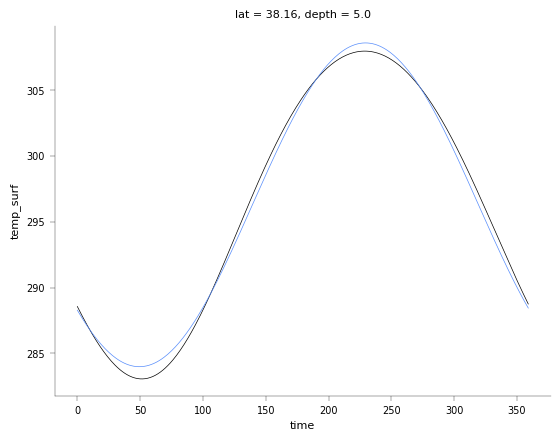

In [21]:
lat_plot_ind = 0
depth_plot_ind = 0

ds_use = ds.isel(lat=lat_plot_ind, depth=depth_plot_ind)
(ds_use.temp_surf).plot(color='k')
# get_fourier_fit_xr(ds_use.time, ds_use.temp_surf, n_harmonics=1, pad_coefs_phase=True)[0].plot()

# Plot theoretical surface temperature annual harmonic using effective feedback parameters
heat_cap_eff_use = (heat_capacity_eff_theory).isel(lat=lat_plot_ind, depth=depth_plot_ind)
lambda_eff_use = (lambda_s1_eff_theory).isel(lat=lat_plot_ind, depth=depth_plot_ind)
# heat_cap_eff_use = (ds.heat_capacity*heat_cap_multiplier).isel(lat=lat_plot_ind, depth=depth_plot_ind)
# lambda_eff_use = lambda_s1_eff.isel(lat=lat_plot_ind, depth=depth_plot_ind)
phase_theory_use = float(np.arctan(omega * heat_cap_eff_use / lambda_eff_use))
amp_theory_use = float(coef_sw_amp.isel(lat=lat_plot_ind, depth=depth_plot_ind) / np.sqrt(
    omega ** 2 * heat_cap_eff_use ** 2 + lambda_eff_use ** 2))
plt.plot(ds.time, fourier_series(ds.time, [float(ds_use.temp_surf.mean()) * 2, -amp_theory_use], [0, phase_theory_use],
                                 pad_coefs_phase=True))

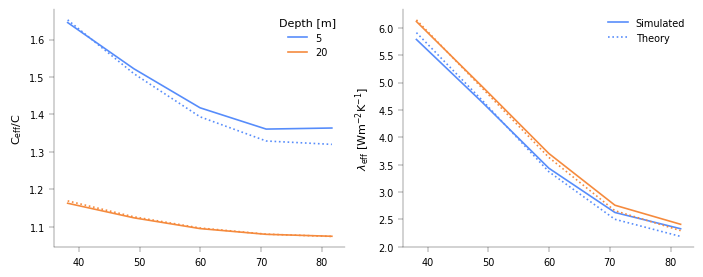

In [22]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].plot(ds.lat, heat_cap_multiplier.isel(depth=i), color=f'C{i}', label=f'{ds.depth[i]:.0f}')
    ax[0].plot(ds.lat, heat_cap_multiplier_theory2.isel(depth=i), color=f'C{i}', linestyle=':')
    ax[1].plot(ds.lat, lambda_s1_eff.isel(depth=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    ax[1].plot(ds.lat, lambda_s1_eff_theory2.isel(depth=i), color=f'C{i}', linestyle=':',
               label='Theory' if i == 0 else None)
update_linewidth(fig)
ax[0].legend(title='Depth [m]')
ax[1].legend()
update_linewidth(fig)
ax[0].set_ylabel("C$_{\\text{eff}}/$C")
ax[1].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
plt.show()

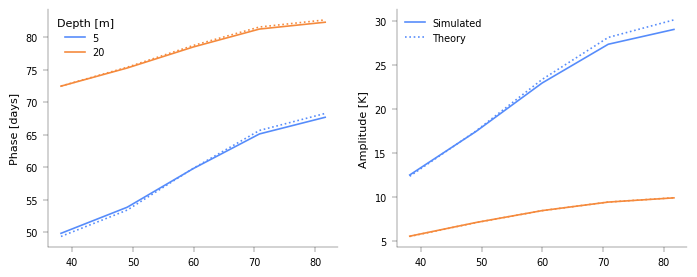

In [23]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].plot(ds.lat, coef_phase.isel(depth=i)/omega/utils.day_seconds, color=f'C{i}', label=f'{ds.depth[i]:.0f}')
    ax[0].plot(ds.lat, coef_phase_theory2.isel(depth=i)/omega/utils.day_seconds, color=f'C{i}', linestyle=':')
    ax[1].plot(ds.lat, coef_amp.isel(depth=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    ax[1].plot(ds.lat, coef_amp_theory2.isel(depth=i), color=f'C{i}', linestyle=':',
               label='Theory' if i == 0 else None)
update_linewidth(fig)
ax[0].legend(title='Depth [m]')
ax[1].legend()
update_linewidth(fig)
ax[0].set_ylabel("Phase [days]")
ax[1].set_ylabel("Amplitude [K]")
plt.show()